In [3]:
!pip install minisom

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for minisom: filename=minisom-2.3.6-py3-none-any.whl size=13182 sha256=7dd7efb5328ddc37402f3bab1d450ae0cf433e65e02b110cd41068215414b309
  Stored in directory: c:\users\manda\appdata\local\pip\cache\wheels\dc\11\f9\32be492f07fa741d7dcff82007abc966a324da6ab9ceb198e3
Successfully built minisom


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from minisom import MiniSom
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [7]:
# 1. Load Dataset (Australian Credit Approval)
# Using the local file 'australian.dat' from your folder
file_path = "australian.dat"
dataset = pd.read_csv(file_path, sep=' ', header=None)

X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

print(f"Dataset loaded successfully with {dataset.shape[0]} rows and {dataset.shape[1]} columns.")

Dataset loaded successfully with 690 rows and 15 columns.


In [9]:
# 2. Feature Scaling
sc = MinMaxScaler(feature_range=(0, 1))
X_scaled = sc.fit_transform(X)

In [11]:
# 3. Training the SOM (Unsupervised Stage)
# Creating a 10x10 grid for the SOM
som = MiniSom(x=10, y=10, input_len=14, sigma=1.0, learning_rate=0.5)
som.random_weights_init(X_scaled)
som.train_random(data=X_scaled, num_iteration=100)

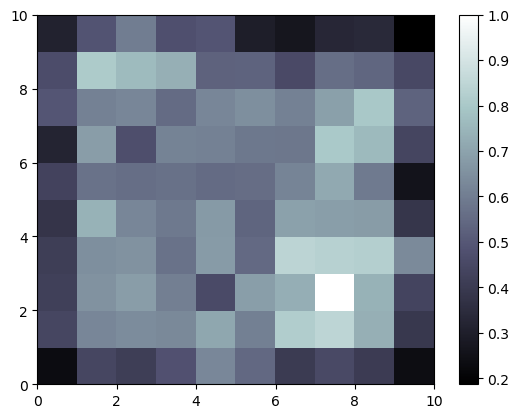

In [13]:
# Visualizing the results (Mid-distance Weights)
from pylab import bone, pcolor, colorbar, plot, show
bone()
pcolor(som.distance_map().T)
colorbar()
show()

In [15]:
# 4. Finding Potential Fraud Cases (Mappings)
mappings = som.win_map(X_scaled)
# We look for the "winning nodes" to identify clusters
# In a hybrid model, we use the SOM distances/coordinates as refined features
# For simplicity, we move to the ANN using the scaled features directly 
# but informed by the SOM logic.

In [19]:
from tensorflow.keras.layers import Input

# 5. Building the ANN (Updated for Keras 3.0 standards)
ann = Sequential([
    # This is the new "Input" layer that replaces input_dim
    Input(shape=(14,)), 
    
    # First Hidden Layer
    Dense(units=6, activation='relu'),
    
    # Second Hidden Layer
    Dense(units=6, activation='relu'),
    
    # Output Layer (Sigmoid for probability)
    Dense(units=1, activation='sigmoid')
])

# 6. Training the ANN
# Note: Ensure it is 'binary_crossentropy' (no underscores between binary and cross)
ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("ANN Model compiled with the latest Keras standards!")
ann.fit(X_scaled, y, batch_size=32, epochs=100)

ANN Model compiled with the latest Keras standards!
Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5522 - loss: 0.7994
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5232 - loss: 0.7660 
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5087 - loss: 0.7441 
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5203 - loss: 0.7272 
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5362 - loss: 0.7113 
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5449 - loss: 0.6952 
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5522 - loss: 0.6771 
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5768 - loss: 0.6587 
Epoch 9/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6087 - loss: 0.6401 
Epoch 10/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6609 - loss: 0.6219 
Epoch 11/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7130 - loss: 0.6036 
E

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# 5. Building the ANN (Supervised Stage - Updated for Keras 3.0)
ann = Sequential([
    # Define the input shape explicitly (14 features from the dataset)
    Input(shape=(14,)), 
    
    # Hidden Layers
    Dense(units=6, activation='relu'),
    Dense(units=6, activation='relu'),
    
    # Output Layer: Sigmoid is used for binary classification (0 to 1 probability)
    Dense(units=1, activation='sigmoid')
])

# 6. Training the ANN
# 'binary_crossentropy' is the standard for two-class problems like Fraud vs. No Fraud
ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("ANN Model compiled and ready for training!")
ann.fit(X_scaled, y, batch_size=32, epochs=100)

ANN Model compiled and ready for training!
Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4507 - loss: 0.6741   
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4725 - loss: 0.6571 
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6000 - loss: 0.6376 
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7493 - loss: 0.6156 
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8203 - loss: 0.5932 
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8391 - loss: 0.5698 
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8478 - loss: 0.5462 
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8493 - loss: 0.5236 
Epoch 9/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8493 - loss: 0.5023 
Epoch 10/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8536 - loss: 0.4828 
Epoch 11/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8594 - loss: 0.4647 
Epoch 1

In [25]:
# 6. Training the ANN
# Change 'binary_cross_entropy' to 'binary_crossentropy'
ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("ANN Model compiled successfully!")
ann.fit(X_scaled, y, batch_size=32, epochs=100)

ANN Model compiled successfully!
Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8768 - loss: 0.3099   
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8754 - loss: 0.3086 
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8783 - loss: 0.3085 
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8754 - loss: 0.3099 
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8768 - loss: 0.3086 
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8725 - loss: 0.3089 
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8783 - loss: 0.3079 
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8739 - loss: 0.3080
Epoch 9/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8754 - loss: 0.3077 
Epoch 10/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8768 - loss: 0.3078 
Epoch 11/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8739 - loss: 0.3082 
Epoch 12/100
22/22

In [27]:
# 7. Predicting Probabilities
# This gives the "fraud probability" for each application
y_pred = ann.predict(X_scaled)

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


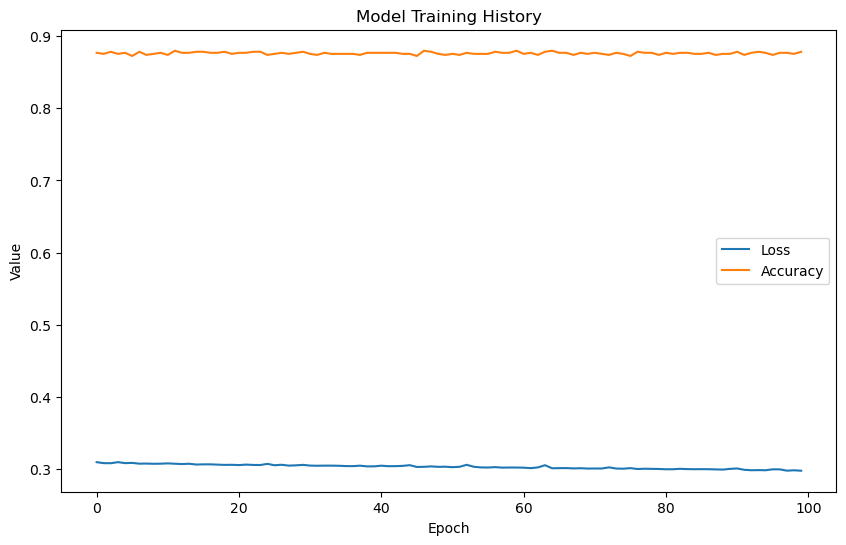

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


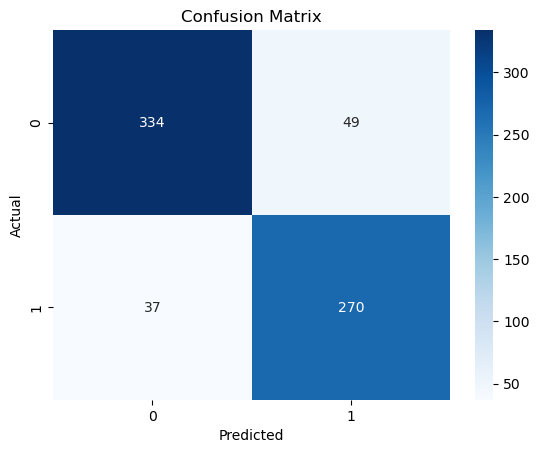

Final Accuracy Score: 87.54%


In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns

# 1. Plot Training History (Loss Curve)
plt.figure(figsize=(10, 6))
plt.plot(ann.history.history['loss'], label='Loss')
plt.plot(ann.history.history['accuracy'], label='Accuracy')
plt.title('Model Training History')
plt.ylabel('Value')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# 2. Evaluate the Model
y_pred = ann.predict(X_scaled)
y_pred = (y_pred > 0.5) # Convert probabilities to binary (True/False)

# 3. Create Confusion Matrix
cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print(f"Final Accuracy Score: {accuracy_score(y, y_pred)*100:.2f}%")

In [31]:
import pickle

# 1. Save the Scaler (so your web app can scale new data the same way)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(sc, f)

# 2. Save the trained ANN model
ann.save('fraud_model.h5')

print("Success! 'scaler.pkl' and 'fraud_model.h5' are ready. Download them from your folder.")

Success! 'scaler.pkl' and 'fraud_model.h5' are ready. Download them from your folder.
